# Téléchargement et exploration des données

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets
import plotly.express as px
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [2]:
# Download data
data_dir = './nilearn_data' # ajout de l'endroit pour télécharger data, plus facile à répliquer ensuite
data = datasets.fetch_adhd(n_subjects=40, data_dir = data_dir) # prend tout le dataset disponible contrairement à étude original

[fetch_adhd] Dataset found in nilearn_data/adhd


In [3]:
# Type de données dans notre data set
data.keys()

dict_keys(['func', 'confounds', 'phenotypic', 'description', 't_r'])

In [4]:
# Transformation de phenotypes en taableau
pheno = pd.DataFrame(data.phenotypic)

In [5]:
# Tous les types de données phénotype possible
pheno.columns 

Index(['Unnamed: 0', 'Subject', 'Rest.Scan', 'MeanFD',
       'NumFD_greater_than_0.20', 'rootMeanSquareFD', 'FDquartile.top1.4thFD.',
       'PercentFD_greater_than_0.20', 'MeanDVARS', 'MeanFD_Jenkinson', 'site',
       'sibling_id', 'data_set', 'age', 'sex', 'handedness', 'full_2_iq',
       'full_4_iq', 'viq', 'piq', 'iq_measure', 'tdc', 'adhd',
       'adhd_inattentive', 'adhd_combined', 'adhd_subthreshold',
       'diagnosis_using_cdis', 'notes', 'sess_1_anat_2', 'oppositional',
       'cog_inatt', 'hyperac', 'anxious_shy', 'perfectionism',
       'social_problems', 'psychosomatic', 'conn_adhd', 'restless_impulsive',
       'emot_lability', 'conn_gi_tot', 'dsm_iv_inatt', 'dsm_iv_h_i',
       'dsm_iv_tot', 'study', 'sess_1_rest_1', 'sess_1_rest_1_eyes',
       'sess_1_rest_2', 'sess_1_rest_2_eyes', 'sess_1_rest_3',
       'sess_1_rest_3_eyes', 'sess_1_rest_4', 'sess_1_rest_4_eyes',
       'sess_1_rest_5', 'sess_1_rest_5_eyes', 'sess_1_rest_6',
       'sess_1_rest_6_eyes', 'sess_1_a

In [6]:
# Vérifier combien de participants ont des données phéno
len(pheno) 

30

Il est anormale que notre dataframe pheno a seulement 30 participants (donc la fonction data.phenotypic ne fonctionne pas correctement). On doit ainsi aller manuellement chercher les données phénotypes pour avoir tous les 40 participants

In [83]:
pheno_all = pd.read_csv('nilearn_data/adhd/ADHD200_40subs_motion_parameters_and_phenotypics.csv')
print(len(pheno_all)) # Vérification qu'il a bien 40 participants maintenant

40


On va regarder les distributions pour les 30 participants et les 40 participants pour visualiser les différences

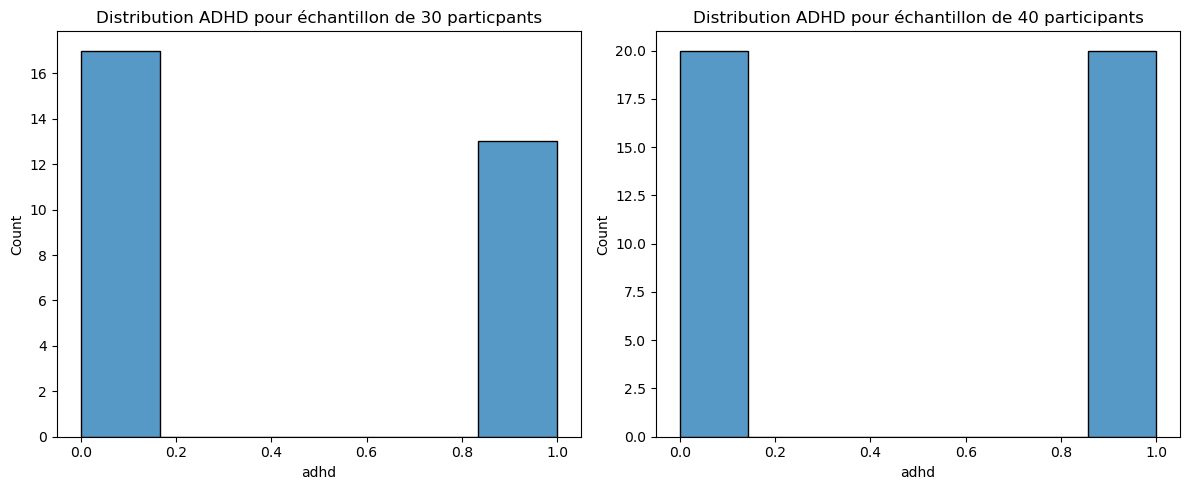

In [8]:
# Regarder la distribution des diagnostics de TDAH
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# échantillon de 30 personnes
sns.histplot(pheno['adhd'], ax=ax1)
ax1.set_title("Distribution ADHD pour échantillon de 30 particpants")

# échantillon de 40 personnes
sns.histplot(pheno_all['adhd'], ax=ax2)
ax2.set_title("Distribution ADHD pour échantillon de 40 participants")

plt.tight_layout()
plt.show()

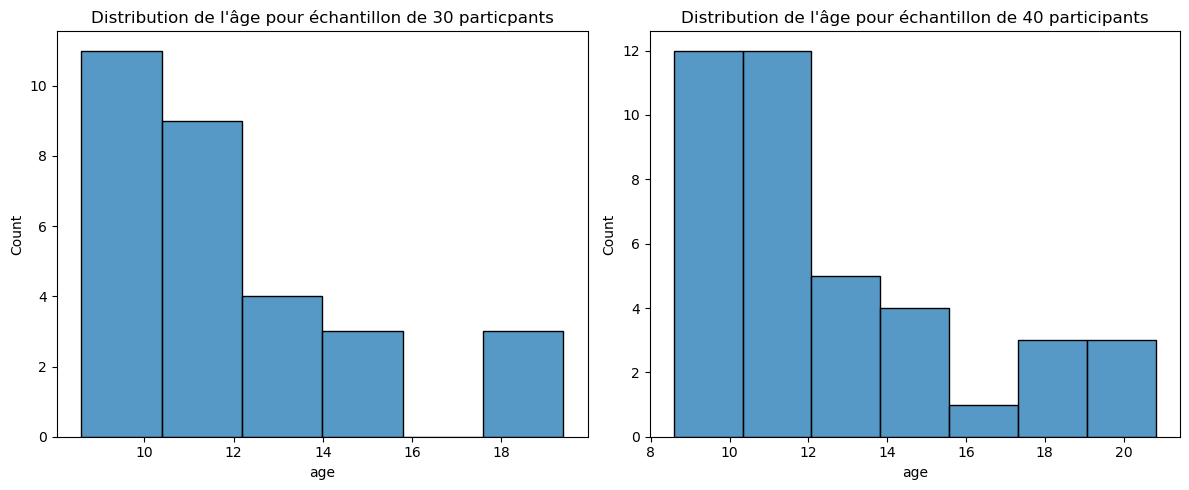

In [9]:
# Regarder la distribution d'âge
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# échantillon de 30 personnes
sns.histplot(pheno['age'], ax=ax1)
ax1.set_title("Distribution de l'âge pour échantillon de 30 particpants")

# échantillon de 40 personnes
sns.histplot(pheno_all['age'], ax=ax2)  
ax2.set_title("Distribution de l'âge pour échantillon de 40 participants")

plt.tight_layout()
plt.show()

In [10]:
# Identifier les sujets manquants de l'échantillon de 30 participants
manquants = set(pheno_all['Subject']) - set(pheno['Subject'])
print(manquants)

{23008, 27011, 23012, 27018, 10128, 10064, 27034, 21019, 10042, 27037}


In [11]:
# Comparaison avec les sujets du projet original
pheno_original = pd.read_csv('projet_original/pheno_table.csv')

diff_pheno40 = set(pheno_all['Subject']) - set(pheno_original['Subject'])
diff_pheno30 = set(pheno['Subject']) - set(pheno_original['Subject'])

print(diff_pheno40)
print(diff_pheno30)

{4134561, 7774305, 4275075, 9750701, 8697774, 9744150, 4046678, 4164316, 6115230, 8409791}
{4134561, 7774305, 4275075, 9750701, 8697774, 9744150, 4046678, 4164316, 6115230, 8409791}


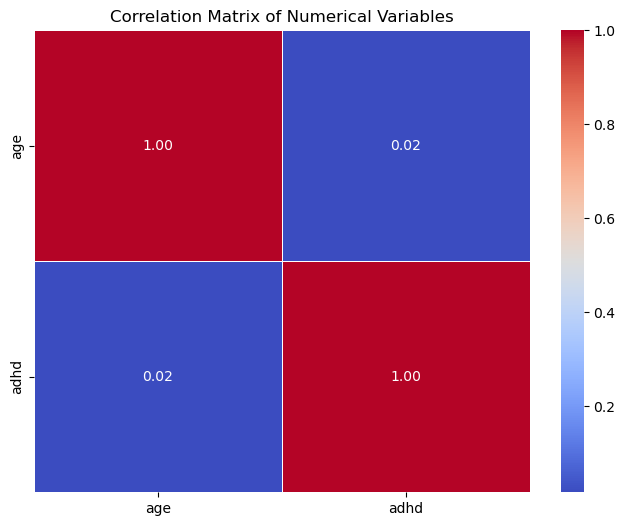

In [12]:
# Matrice de corrélation de l'âge et du diagnostic TDAH 
numerical_cols = ['age', 'adhd']
df_numeric = pheno_all[numerical_cols]

# Compute the correlation matrix
correlation_matrix = df_numeric.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

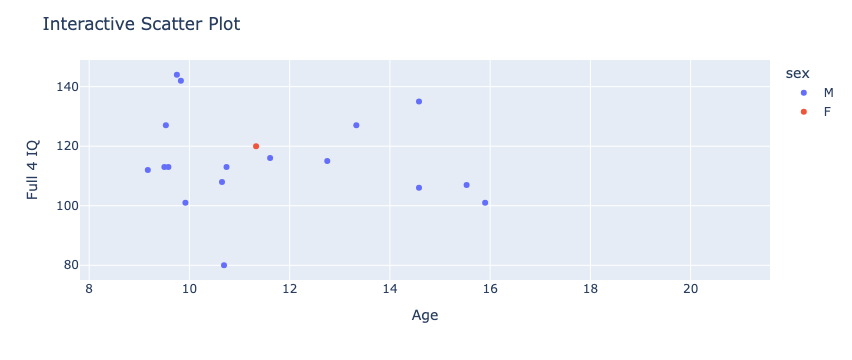

In [13]:
# Reproduction du scatter plot
fig = px.scatter(pheno_all, x='age', y='full_4_iq', color='sex', hover_data=['adhd', 'cog_inatt', 'hyperac', 'anxious_shy', 'perfectionism',
       'social_problems','conn_adhd', 'restless_impulsive',])

fig.update_layout(
    title="Interactive Scatter Plot",
    xaxis_title="Age",
    yaxis_title="Full 4 IQ"
)

fig.show()

In [14]:
# Vérification de pourquoi graphique différent que projet initial
print(pheno_all[['age', 'full_4_iq']].isna().sum())

age           0
full_4_iq    22
dtype: int64



Contrairement au projet original, l'utilisation de son code ne montre pas les participants qui n'ont pas de valeur au full_4_iq (notre graphique présente 22 participants de moins). Je préfère cette visualisation que l'original qui met un peu arbitrairement les données manquantes au milieu du graphique, induisant un peu en erreur l'interprétation de la figure


# Préparation des données

In [15]:
from nilearn.input_data import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import plotting
from nilearn import image
from nilearn.plotting import plot_connectome

/var/folders/rw/8w59v3ld03q_jn0m9p0qxr1r0000gn/T/ipykernel_45965/2884611696.py:1: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


## Extraction des features

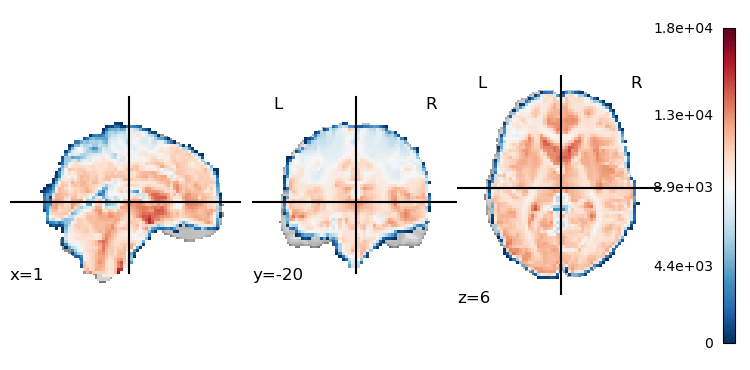

In [16]:
# Image moyenne pour séries temporelles d'un sujet
fmri_filenames = data.func[0]
averaged_Img = image.mean_img(fmri_filenames)
plotting.plot_stat_map(averaged_Img) 

Il semble avoir eu un changement dans la valeur par défaut pour le cmap. Le projet original avait cmap = 'cold_hot' sans la mentionner directement dans le code tandis que la valeur par défaut dans la présente version de nilearn est 'RdBu_r'

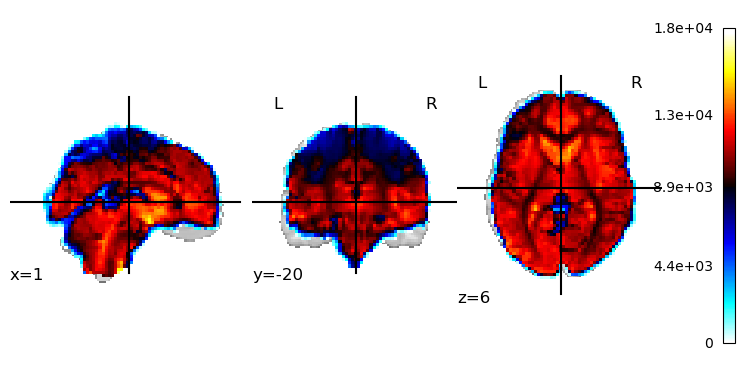

In [17]:
# Pour avoir la même figure que le projet original
plotting.plot_stat_map(averaged_Img, cmap='cold_hot') 

In [18]:
#Importer l'atlas
parcellations = datasets.fetch_atlas_basc_multiscale_2015(version='sym', resolution=64) 
atlas_filename = parcellations.maps 

[fetch_atlas_basc_multiscale_2015] Dataset found in /Users/anhthinguyen/nilearn_data/basc_multiscale_2015


MODIFICATION: Avec le présente version de nilearn, on doit maintenant préciser quelle résolution on veut lorsqu'on fetch l'atlas, semble qu'ancienne version retournait toutes les versions en même temps. Les keys ont également changer, donc on doit faire parcellations.maps pour avoir le file_name de l'atlas

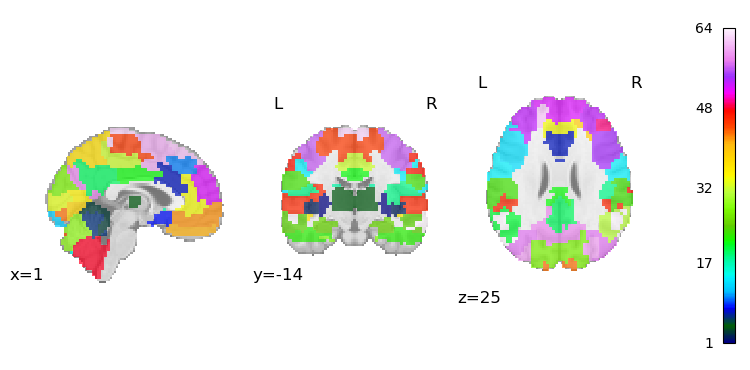

In [19]:
#Plot atlas
plotting.plot_roi(atlas_filename, draw_cross = False)

In [74]:
# Création du masque
mask = NiftiLabelsMasker(labels_img=atlas_filename, 
                           standardize='zscore_sample', #standardize = True est deprecated et donne pleins de warnings
                           memory='nilearn_cache', 
                           verbose=0)

# Initialisation de la mesure de corrélation
correlation_measure = ConnectivityMeasure(kind='correlation', vectorize=True,
                                         discard_diagonal=True, standardize='zscore_sample')

In [75]:
# Matrice de corrélation pour tous les sujets
all_features= []

for i, sub in enumerate(data.func):
    # Extraction des séries temporelles
    time_series = mask.fit_transform(sub, confounds=data.confounds[i])
    
    # Création de la matrice pour le sujet
    correlation_matrix = correlation_measure.fit_transform([time_series])[0]
    
    # Append features and file name to the list
    all_features.append(correlation_matrix)

MODIFICATION: 
Il y a de l'incohérence dans le projet original. Il initialise une mesure de corrélation qui enlève la diagonale et vectorize = True donc garde seulement le triangle inférieur + flatten puis retourne un array de 1D. Par contre, dans la boucle pour faire la matrice de corrélation pour tous les sujets, on reinitialise la mesure de corrélation sans enlever la diagonale et avec vectorize = False ce qui retourne un array de 2D. L'array de 2D est utile pour les visualisations (comme fait dans le projet original), mais utiliser ce type d'array donne de l'information qui est redondante pour les modèles de classifications.

Pour mon projet, je préfère donc utiliser la mesure de connectivité sans la diagonale et avec seulement le triangle inférieur puisque le but principal de ce projet est les classificateurs. Par contre, je vais utiliser la méthode discard_diagonal = False et vectorize = False pour faire les mêmes visualisations que le projet original (mais cette méthode n'est pas utiliser pour les classificateur)

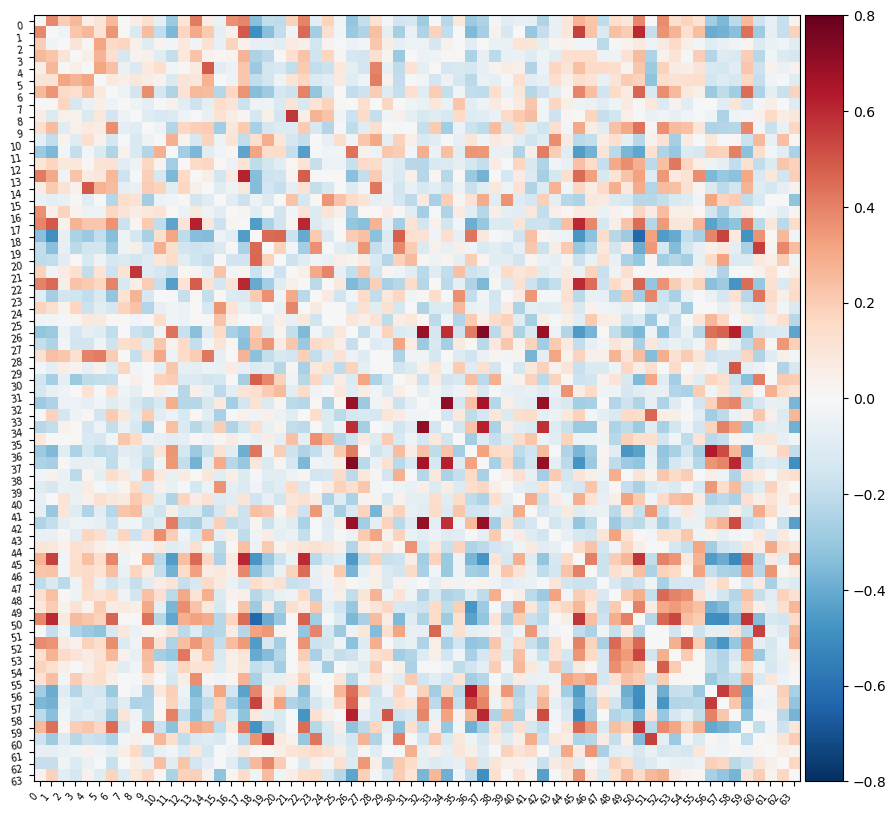

In [76]:
# Pour la visualisation seulement
correlation_measure_figure = ConnectivityMeasure(kind='correlation', standardize='zscore_sample')

# Pour un sujet
time_series_figure = mask.fit_transform(data.func[0], confounds=data.confounds[0])
correlation_matrix_2d = correlation_measure_figure.fit_transform([time_series_figure])[0]

np.fill_diagonal(correlation_matrix_2d, 0)
plotting.plot_matrix(correlation_matrix_2d, figure=(10, 8),
                     labels=range(correlation_matrix_2d.shape[0]),
                     vmax=0.8, vmin=-0.8, reorder=False)

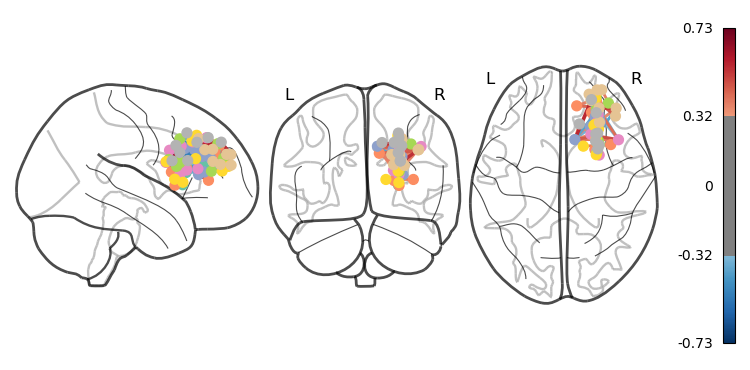

In [77]:
import nibabel as nib
import numpy as np

# Load the atlas image for the desired scale
atlas_img = nib.load(atlas_filename)

# Extract the data from the atlas image
atlas_data = atlas_img.get_fdata()

# Assuming the atlas data provides labels for each region
# You can use these labels to extract coordinates if available
# For example, if the atlas data is a 3D volume where each region is represented by a unique label,
# you can extract the coordinates of each label using numpy's `where` function:
label_coordinates = []
unique_labels = np.unique(atlas_data)
for label in unique_labels:
    if label != 0:  # Exclude background label if present
        label_coords = np.where(atlas_data == label)
        # Calculate the centroid or any other representative coordinate for the label if needed
        centroid = np.mean(label_coords, axis=1)
        label_coordinates.append(centroid)

# Now `label_coordinates` contains the coordinates of each region in the atlas

# We threshold to keep only the 10% of edges with the highest value
# because the graph is very dense
plot_connectome(correlation_matrix_2d, label_coordinates,
                edge_threshold="90%", colorbar=True)

## Labeling des données

In [84]:
#Ajouter les features au dataframe des phénotypes
feature_series = pd.Series(all_features, name='features')
pheno_all = pd.concat([pheno_all, feature_series], axis=1)

In [85]:
# Sauvegarder le dataframe final qu'on va utiliser pour la classification
path = './pheno_table.csv' #même nom que le projet original pour cohérence
pheno_all.to_csv(path, index=False)

Text(0, 0.5, 'subjects')

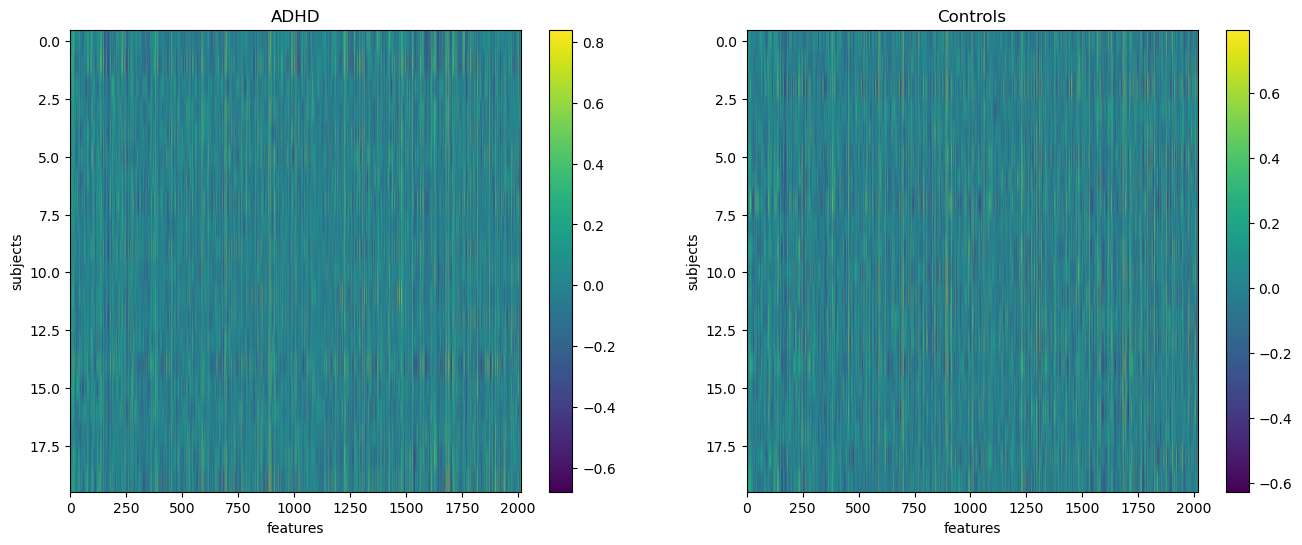

In [86]:
#Plot correlation matrix for 'adhd' and 'control' subjects 
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, savefig

adhd_features = list(pheno_all.loc[pheno_all['adhd']==1]['features'])
control_features = list(pheno_all.loc[pheno_all['adhd']==0]['features'])

figure(figsize=(16,6))

plt.subplot(1, 2, 1)
plt.imshow(adhd_features, aspect='auto')
plt.colorbar()
plt.title('ADHD')
plt.xlabel('features')
plt.ylabel('subjects')


plt.subplot(1, 2, 2)
plt.imshow(control_features, aspect='auto')
plt.colorbar()
plt.title('Controls')
plt.xlabel('features')
plt.ylabel('subjects')